In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import os

<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:34: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:34: SyntaxWarning: invalid escape sequence '\o'
/var/folders/85/3hlfymdd0mg01kbks_s9w5mc0000gn/T/ipykernel_6525/498394800.py:33: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_xlabel("$\omega_1$")
/var/folders/85/3hlfymdd0mg01kbks_s9w5mc0000gn/T/ipykernel_6525/498394800.py:34: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_ylabel("$\omega_2$")


--- SUCCESS ---
File saved as: kernel_spectral_analysis.png
Location: /Users/lilave/Desktop/Deterministic-Verification-of-CNN-Stability-via-the-Bivariate-Z-Transform/extracted_kernels/Notebooks/kernel_spectral_analysis.png


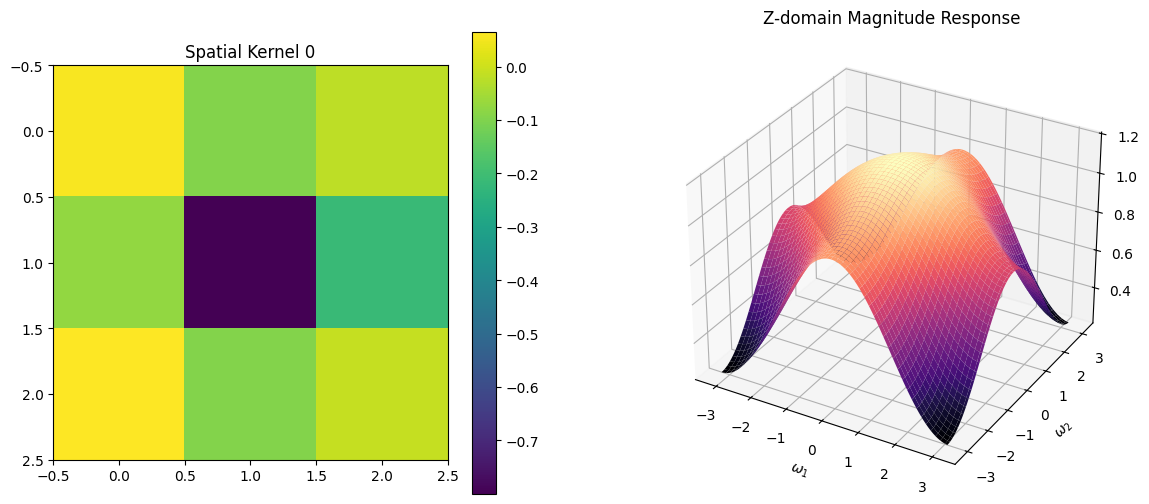

In [4]:

def analyzeKernelsSpectral(csvFile):
    # Load and reshape
    df = pd.read_csv(csvFile)
    kernels = df.values.reshape(-1, 3, 3)

    # Select sample
    sampleIdx = 0 
    h = kernels[sampleIdx] 

    # Evaluate the Z-transform
    gridSize = 100
    H = np.fft.fft2(h, s=(gridSize, gridSize))
    HShifted = np.fft.fftshift(H)
    magnitude = np.abs(HShifted)    

    # Create the frequency axis - FIXED p.pi to np.pi
    omega = np.linspace(-np.pi, np.pi, gridSize)
    W1, W2 = np.meshgrid(omega, omega)

    # Visualize
    fig = plt.figure(figsize=(14, 6))

    # Spatial Plot
    ax1 = fig.add_subplot(121)
    im1 = ax1.imshow(h, cmap="viridis")
    ax1.set_title(f"Spatial Kernel {sampleIdx}")
    plt.colorbar(im1, ax=ax1)

    # Z-domain Surface - FIXED ax to ax2
    ax2 = fig.add_subplot(122, projection="3d")
    surf = ax2.plot_surface(W1, W2, magnitude, cmap="magma", edgecolor="none")
    ax2.set_title("Z-domain Magnitude Response")
    ax2.set_xlabel("$\omega_1$")
    ax2.set_ylabel("$\omega_2$")

    # Save and Print Path
    filename = "kernel_spectral_analysis.png"
    plt.savefig(filename)
    print(f"--- SUCCESS ---")
    print(f"File saved as: {filename}")
    print(f"Location: {os.path.abspath(filename)}")
    
    plt.show()

if __name__ == "__main__":
    # Make sure this filename matches your actual CSV filename
    analyzeKernelsSpectral("resnet18_layer1_3x3.csv")